In [6]:
import oqupy
import oqupy.operators as op
import numpy as np
import matplotlib.pyplot as plt
import time

import numpy as np
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from scipy.optimize import minimize,Bounds

pt_parameters = {'tmax':20,
                 'steps':65, 
                 'dkmax':30,
                 'epsrel':10**(-7),
                 'alpha':0.1,
                 'omega_cutoff':1,                 
                 'temp':0.131}

omega_cutoff = pt_parameters['omega_cutoff']
alpha = pt_parameters['alpha']
temperature = pt_parameters['temp']
epsrel = pt_parameters['epsrel']
t_max = pt_parameters['tmax']
# dt = 1./omega_cutoff/np.sqrt(3)
num_steps = pt_parameters['steps']
dt = t_max/num_steps
dkmax = pt_parameters['dkmax']

t_list = np.linspace(0,t_max,num_steps+1)

tcut=25


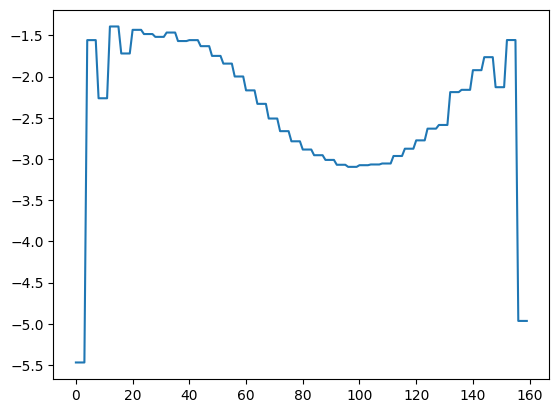

In [23]:
# checking convergence of optimal controls
control_params=[[-5.47017154],[-5.47017154],
 [-5.47017154],
 [-5.47017154],
 [-1.55805834],
 [-1.55805834],
 [-1.55805834],
 [-1.55805834],
 [-2.26373102],
 [-2.26373102],
 [-2.26373102],
 [-2.26373102],
 [-1.39255495],
 [-1.39255495],
 [-1.39255495],
 [-1.39255495],
 [-1.72026323],
 [-1.72026323],
 [-1.72026323],
 [-1.72026323],
 [-1.43335097],
 [-1.43335097],
 [-1.43335097],
 [-1.43335097],
 [-1.48435187],
 [-1.48435187],
 [-1.48435187],
 [-1.48435187],
 [-1.51862662],
 [-1.51862662],
 [-1.51862662],
 [-1.51862662],
 [-1.46615763],
 [-1.46615763],
 [-1.46615763],
 [-1.46615763],
 [-1.56931244],
 [-1.56931244],
 [-1.56931244],
 [-1.56931244],
 [-1.5582176 ],
 [-1.5582176 ],
 [-1.5582176 ],
 [-1.5582176 ],
 [-1.63143378],
 [-1.63143378],
 [-1.63143378],
 [-1.63143378],
 [-1.74962694],
 [-1.74962694],
 [-1.74962694],
 [-1.74962694],
 [-1.8430782 ],
 [-1.8430782 ],
 [-1.8430782 ],
 [-1.8430782 ],
 [-1.99951197],
 [-1.99951197],
 [-1.99951197],
 [-1.99951197],
 [-2.16794388],
 [-2.16794388],
 [-2.16794388],
 [-2.16794388],
 [-2.33154474],
 [-2.33154474],
 [-2.33154474],
 [-2.33154474],
 [-2.50965445],
 [-2.50965445],
 [-2.50965445],
 [-2.50965445],
 [-2.66288336],
 [-2.66288336],
 [-2.66288336],
 [-2.66288336],
 [-2.78604472],
 [-2.78604472],
 [-2.78604472],
 [-2.78604472],
 [-2.88597096],
 [-2.88597096],
 [-2.88597096],
 [-2.88597096],
 [-2.95480995],
 [-2.95480995],
 [-2.95480995],
 [-2.95480995],
 [-3.01190287],
 [-3.01190287],
 [-3.01190287],
 [-3.01190287],
 [-3.07084028],
 [-3.07084028],
 [-3.07084028],
 [-3.07084028],
 [-3.09615573],
 [-3.09615573],
 [-3.09615573],
 [-3.09615573],
 [-3.07603913],
 [-3.07603913],
 [-3.07603913],
 [-3.07603913],
 [-3.06729369],
 [-3.06729369],
 [-3.06729369],
 [-3.06729369],
 [-3.05542225],
 [-3.05542225],
 [-3.05542225],
 [-3.05542225],
 [-2.96434025],
 [-2.96434025],
 [-2.96434025],
 [-2.96434025],
 [-2.8759399 ],
 [-2.8759399 ],
 [-2.8759399 ],
 [-2.8759399 ],
 [-2.77470568],
 [-2.77470568],
 [-2.77470568],
 [-2.77470568],
 [-2.63245397],
 [-2.63245397],
 [-2.63245397],
 [-2.63245397],
 [-2.58778833],
 [-2.58778833],
 [-2.58778833],
 [-2.58778833],
 [-2.18900498],
 [-2.18900498],
 [-2.18900498],
 [-2.18900498],
 [-2.16141555],
 [-2.16141555],
 [-2.16141555],
 [-2.16141555],
 [-1.92280681],
 [-1.92280681],
 [-1.92280681],
 [-1.92280681],
 [-1.76502726],
 [-1.76502726],
 [-1.76502726],
 [-1.76502726],
 [-2.12944517],
 [-2.12944517],
 [-2.12944517],
 [-2.12944517],
 [-1.5571027 ],
 [-1.5571027 ],
 [-1.5571027 ],
 [-1.5571027 ],
 [-4.96590484],
 [-4.96590484],
 [-4.96590484],
 [-4.96590484]]

control_params= [
    x
    for xs in control_params
    for x in xs
]

plt.plot(control_params)

In [15]:
delta_t = interp1d(np.linspace(0,20,len(control_params)),control_params)

building influence functional:  27%|██▋       | 27/100 [00:00<00:00, 259.97it/s]

building influence functional: 100%|██████████| 100/100 [00:21<00:00,  4.55it/s]


rank  396
--> Compute dynamics:
100.0%   80 of   80 [########################################] 00:00:19
Elapsed time: 19.3s


building influence functional:  12%|█▏        | 24/200 [00:00<00:00, 238.53it/s]

building influence functional: 100%|██████████| 200/200 [00:49<00:00,  4.04it/s]


...

rank  134
--> Compute dynamics:
100.0%   80 of   80 [########################################] 00:00:13
Elapsed time: 13.3s


building influence functional: 100%|██████████| 100/100 [00:00<00:00, 1115.98it/s]

rank  12
--> Compute dynamics:
  1.2%    1 of   80 [----------------------------------------] 00:00:00

100.0%   80 of   80 [########################################] 00:00:10
Elapsed time: 10.8s


/var/folders/s8/7dsl0tws32199pt1sh7flrsw0000gn/T/ipykernel_90673/67907072.py:85: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig1.show()


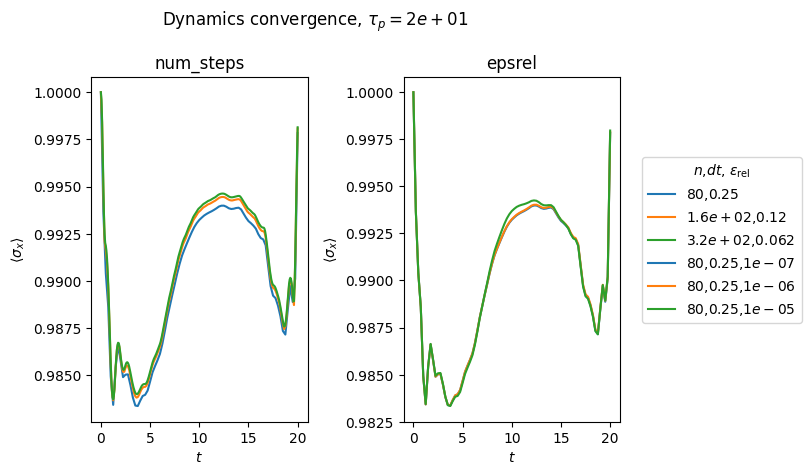

In [20]:
import oqupy as oqupy
from oqupy.iTEBD_TEMPO_useoqupybath import iTEBD_TEMPO_oqupy
from oqupy.process_tensor import TTInvariantProcessTensor
from oqupy.tti_tempo import TTITempo
from oqupy.tti_tempo import TTITempoCounting
import numpy as np
import matplotlib.pyplot as plt

# Dynamics calculations convergence

fig1,axs1 = plt.subplots(1,2)
fig1.suptitle('TTI Dynamics Convergence')

# spectral density (without cutoff)
def j(w):
    return 2*alpha*w

correlations = oqupy.PowerLawSD(alpha=alpha,
                                zeta=1,
                                cutoff=omega_cutoff,
                                cutoff_type='exponential',
                                temperature=temperature)
bath = oqupy.Bath(op.sigma("z")/2.0, correlations)
parameters=oqupy.TempoParameters(dt=dt,epsrel=epsrel,dkmax=dkmax)
'''
def hamiltonian_t(t):
    return pt_parameters['omega_cutoff']*op.sigma('x')*t/2 *(1/t_max)
'''

delta_t = interp1d(np.linspace(0,20,len(control_params)),control_params)
def hamiltonian_t(t):
    return delta_t(t)*oqupy.operators.sigma("x")/2


system = oqupy.TimeDependentSystem(hamiltonian_t)

Rho_0=oqupy.operators.spin_dm('x+')

for num in [len(control_params)//2,len(control_params),2*len(control_params)]:

    parameter_var=oqupy.TempoParameters(dt=t_max/num,epsrel=epsrel,dkmax=int(tcut*num/t_max))
    pt_var=TTITempo(bath,start_time=0.0,parameters=parameter_var)
    process_tensor_var = pt_var.get_process_tensor()

    dynamics=oqupy.compute_dynamics(
       process_tensor=process_tensor_var,        
       system=system,
       initial_state=Rho_0,
       start_time=0,
       num_steps=num)
    t, s_x = dynamics.expectations(op.sigma('x'), real=True)
    axs1[0].plot(t,s_x, label=r'${:.2g}$,${:.2g}$'.format(num,t_max/num))
    
    axs1[0].set_xlabel(r'$t$')
    axs1[0].set_ylabel(r'$\langle \sigma_x \rangle$')
    axs1[0].set_title(r'num_steps')

num_con=len(control_params)//2

for epsrel_var in [1e-07,1e-06,1e-05]:

    parameter_var=oqupy.TempoParameters(dt=t_max/num_con,epsrel=epsrel_var,dkmax=int(tcut*num_con/t_max))
    pt_var=TTITempo(bath,start_time=0.0,parameters=parameter_var)
    process_tensor_var = pt_var.get_process_tensor()

    dynamics=oqupy.compute_dynamics(
       process_tensor=process_tensor_var,        
       system=system,
       initial_state=Rho_0,
       start_time=0,
       num_steps=num_con)
    t, s_x = dynamics.expectations(op.sigma('x'), real=True)
    axs1[1].plot(t,s_x, label=r'${:.2g}$,${:.2g}$,${:.2g}$'.format(num_con,t_max/num_con,epsrel_var))
    
    axs1[1].set_xlabel(r'$t$')
    axs1[1].set_ylabel(r'$\langle \sigma_x \rangle$')
    axs1[1].set_title(r'epsrel')

lines_labels=[ax.get_legend_handles_labels() for ax in fig1.axes]
lines,labels = [sum(lol,[]) for lol in zip( *lines_labels)]
fig1.legend(lines,labels,loc='center left',bbox_to_anchor=(1,0.5),ncol=1,title=r'$n$,$dt$, $\epsilon_{\text{rel}}$')
fig1.suptitle(r'Dynamics convergence, $\tau_p={:.1g}$'.format(t_max))
fig1.tight_layout()
fig1.show()


building influence functional:  40%|████      | 25/62 [00:00<00:00, 245.90it/s]

building influence functional: 100%|██████████| 62/62 [00:07<00:00,  8.53it/s] 

rank  329
--> Compute dynamics:
  0.0%    0 of   50 [----------------------------------------] 00:00:00

100.0%   50 of   50 [########################################] 00:00:12
Elapsed time: 12.1s
0.007438350634571852


building influence functional:  19%|█▉        | 24/125 [00:00<00:00, 236.23it/s]

...

rank  385
--> Compute dynamics:
100.0%  100 of  100 [########################################] 00:00:17
Elapsed time: 17.3s
0.003193509177446724


building influence functional: 100%|██████████| 125/125 [00:00<00:00, 1025.33it/s]

rank  20
--> Compute dynamics:
  1.0%    1 of  100 [----------------------------------------] 00:00:00

100.0%  100 of  100 [########################################] 00:00:13
Elapsed time: 13.4s
0.0027451179007105023


/var/folders/s8/7dsl0tws32199pt1sh7flrsw0000gn/T/ipykernel_90673/1556616779.py:69: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig2.show()
/var/folders/s8/7dsl0tws32199pt1sh7flrsw0000gn/T/ipykernel_90673/1556616779.py:76: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig3.show()


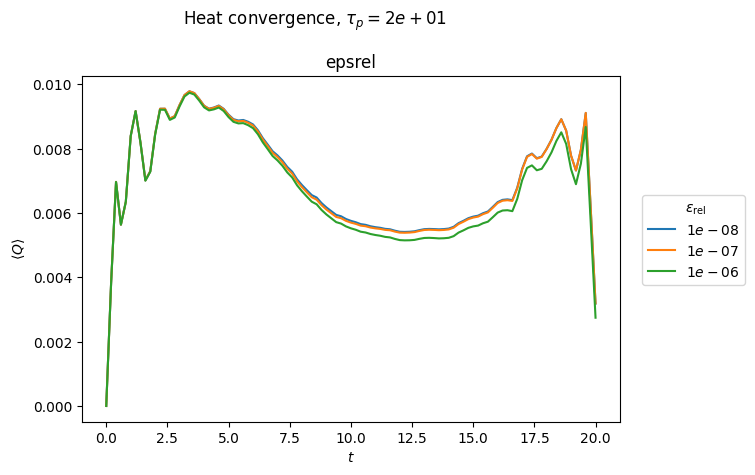

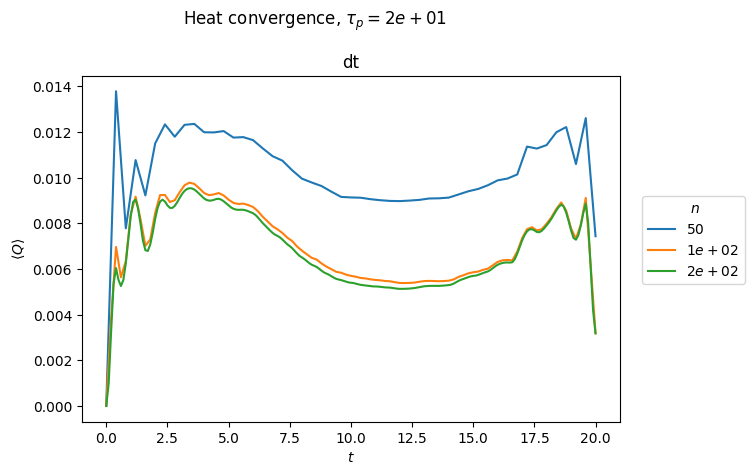

In [22]:
import cProfile, pstats, io
from pstats import SortKey

u=0.01
correlationscf=oqupy.bath_correlations.CustomCountingSD(j_function=j,cutoff=omega_cutoff,u=u,
                                                 cutoff_type='exponential',temperature=temperature)

bathcf = oqupy.Bath(op.sigma("z")/2.0, correlationscf)

fig2,axs2=plt.subplots(1,1)
fig3,axs3=plt.subplots(1,1)

for num_steps_var in [50,100,200]:

    parameter_var=oqupy.TempoParameters(dt=t_max/num_steps_var,epsrel=epsrel,dkmax=int(tcut*num_steps_var/t_max))
    pt_varcf=TTITempoCounting(bathcf,start_time=0.0,parameters=parameter_var)
    process_tensor_varcf = pt_varcf.get_process_tensor()

    dynamics = oqupy.compute_dynamics(
       process_tensor=process_tensor_varcf,        
       system=system,
       initial_state=Rho_0,
       start_time=0,
       num_steps=num_steps_var)

    heats=dynamics.states.trace(axis1=1,axis2=2).imag/u
    print(heats[-1])
    axs3.plot(dynamics.times,heats, label=r'${:.2g}$'.format(num_steps_var))

    axs3.set_xlabel(r'$t$')
    axs3.set_ylabel(r'$\langle Q \rangle$')
    axs3.set_title(r'dt')

num_steps=100

for epsrel_var in reversed([1e-06,1e-07,1e-08]):

    parameter_var=oqupy.TempoParameters(dt=t_max/num_steps,epsrel=epsrel_var,dkmax=int(tcut*num_steps/t_max))
    pt_varcf=TTITempoCounting(bathcf,start_time=0.0,parameters=parameter_var)
    process_tensor_varcf = pt_varcf.get_process_tensor()

    dynamics = oqupy.compute_dynamics(
       process_tensor=process_tensor_varcf,        
       system=system,
       initial_state=Rho_0,
       start_time=0,
       num_steps=num_steps)

    heats=dynamics.states.trace(axis1=1,axis2=2).imag/u
    print(heats[-1])
    axs2.plot(dynamics.times,heats, label=r'${:.2g}$'.format(epsrel_var))
    axs2.set_xlabel(r'$t$')
    axs2.set_ylabel(r'$\langle Q \rangle$')
    axs2.set_title(r'epsrel')

lines_labels=[ax.get_legend_handles_labels() for ax in fig2.axes]
lines,labels = [sum(lol,[]) for lol in zip( *lines_labels)]
fig2.legend(lines,labels,loc='center left',bbox_to_anchor=(1,0.5),ncol=1,title=r' $\epsilon_{\text{rel}}$')
fig2.suptitle(r'Heat convergence, $\tau_p={:.1g}$'.format(t_max))
fig2.tight_layout()
fig2.show()

lines_labels=[ax.get_legend_handles_labels() for ax in fig3.axes]
lines,labels = [sum(lol,[]) for lol in zip( *lines_labels)]
fig3.legend(lines,labels,loc='center left',bbox_to_anchor=(1,0.5),ncol=1,title=r' $n$')
fig3.suptitle(r'Heat convergence, $\tau_p={:.1g}$'.format(t_max))
fig3.tight_layout()
fig3.show()


In [110]:
# Generating the heat marked process tensors

protocol_times=[10,50,70,100,200]

parameter_dict= {protocol_times[0]:{'num_steps':50,'epsrel':1e-07},
                 protocol_times[1]:{'num_steps':100,'epsrel':1e-07}, 
                 protocol_times[2]:{'num_steps':140,'epsrel':1e-06},
                 protocol_times[3]:{'num_steps':200,'epsrel':1e-06},
                 protocol_times[4]:{'num_steps':400,'epsrel':1e-06}}

heats_dict={protocol_times[0]:[],
                 protocol_times[1]:[], 
                 protocol_times[2]:[],
                 protocol_times[3]:[],
                 protocol_times[4]:[]}

dyn_dict={protocol_times[0]:[],
                 protocol_times[1]:[], 
                 protocol_times[2]:[],
                 protocol_times[3]:[],
                 protocol_times[4]:[]}

cfpt_dict={protocol_times[0]:[],
                 protocol_times[1]:[], 
                 protocol_times[2]:[],
                 protocol_times[3]:[],
                 protocol_times[4]:[]}

for t_prot in protocol_times:
    def hamiltonian_t(t):
        return pt_parameters['omega_cutoff']*op.sigma('x')*t/2 *(1/t_prot)

    system = oqupy.TimeDependentSystem(hamiltonian_t)
    num_steps=parameter_dict[t_prot]['num_steps']
    epsrel=parameter_dict[t_prot]['epsrel']

    parameter_var=oqupy.TempoParameters(dt=t_prot/num_steps,epsrel=epsrel,dkmax=2*int(tcut*num_steps/t_prot))
    pt_var=TTITempo(bath,start_time=0.0,parameters=parameter_var)
    process_tensor_var = pt_var.get_process_tensor()

    dynamics=oqupy.compute_dynamics(
       process_tensor=process_tensor_var,        
       system=system,
       initial_state=Rho_0,
       start_time=0,
       num_steps=num_steps)
    t, s_x = dynamics.expectations(op.sigma('x'), real=True)

    pt_varcf=TTITempoCounting(bathcf,start_time=0.0,parameters=parameter_var)
    process_tensor_varcf = pt_varcf.get_process_tensor()

    dynamicscf = oqupy.compute_dynamics(
       process_tensor=process_tensor_varcf,        
       system=system,
       initial_state=Rho_0,
       start_time=0,
       num_steps=num_steps)

    heats=dynamicscf.states.trace(axis1=1,axis2=2).imag/u

    cfpt_dict[t_prot]=process_tensor_varcf
    dyn_dict[t_prot]=s_x
    heats_dict[t_prot]=heats

 93.9%  169 of  180 [#####################################---] 01:05:54

building influence functional: 100%|██████████| 105/105 [00:00<00:00, 568.79it/s]


rank  20
--> Compute dynamics:
100.0%   50 of   50 [########################################] 00:00:02
Elapsed time: 2.5s
 93.9%  169 of  180 [#####################################---] 01:06:07

building influence functional:   0%|          | 0/105 [00:00<?, ?it/s]

building influence functional:  89%|████████▊ | 93/105 [00:00<00:00, 899.10it/s]

...

building influence functional:  57%|█████▋    | 24/42 [00:00<00:00, 228.89it/s]

 36.0%   45 of  125 [##############--------------------------] 11:00:52

building influence functional: 100%|██████████| 42/42 [00:00<00:00, 52.49it/s] 

rank  135
--> Compute dynamics:
  0.5%    2 of  400 [----------------------------------------] 00:00:00

100.0%  400 of  400 [########################################] 00:00:16
Elapsed time: 16.9s


 36.0%   45 of  125 [##############--------------------------] 11:01:09

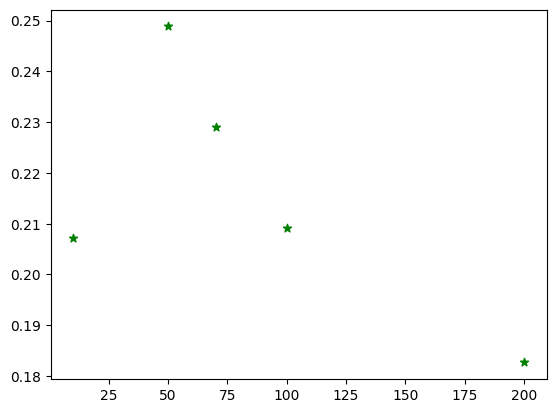

In [111]:
final_heats=[]
for t in protocol_times:
    final_heats.append(heats_dict[t][-1])

plt.scatter(protocol_times,final_heats,marker='*',c='green')

In [112]:
parameter_fine=oqupy.TempoParameters(dt=0.5,epsrel=1e-06,dkmax=int(tcut/(0.5)))
pt_varcf=TTITempoCounting(bathcf,start_time=0.0,parameters=parameter_fine)
process_tensor_fine= pt_varcf.get_process_tensor()

 36.0%   45 of  125 [##############--------------------------] 11:01:12

building influence functional:  57%|█████▋    | 24/42 [00:00<00:00, 223.10it/s]

 93.9%  169 of  180 [#####################################---] 01:07:53

building influence functional: 100%|██████████| 42/42 [00:00<00:00, 42.76it/s] 

rank  135


In [113]:
tti_pt_heats=[]
for t_prot in range(10,200,10):
   def hamiltonian_t(t):
      return pt_parameters['omega_cutoff']*op.sigma('x')*t/2 *(1/(t_prot))

   system = oqupy.TimeDependentSystem(hamiltonian_t)
   dynamics = oqupy.compute_dynamics(
       process_tensor=process_tensor_fine,        
       system=system,
       initial_state=Rho_0,
       start_time=0,
       num_steps=int(t_prot/(0.5)))
   heat_f=dynamics.states.trace(axis1=1,axis2=2).imag/0.01
   tti_pt_heats.append(heat_f[-1])

--> Compute dynamics:
100.0%   20 of   20 [########################################] 00:00:00
Elapsed time: 0.8s
--> Compute dynamics:
100.0%   40 of   40 [########################################] 00:00:01
Elapsed time: 1.7s
--> Compute dynamics:
100.0%   60 of   60 [########################################] 00:00:02
Elapsed time: 2.6s
--> Compute dynamics:
100.0%   80 of   80 [########################################] 00:00:03
Elapsed time: 3.4s
--> Compute dynamics:
100.0%  100 of  100 [########################################] 00:00:04
Elapsed time: 4.4s
--> Compute dynamics:
100.0%  120 of  120 [########################################] 00:00:04
Elapsed time: 4.7s
--> Compute dynamics:
100.0%  140 of  140 [########################################] 00:00:05
Elapsed time: 5.9s
--> Compute dynamics:
100.0%  160 of  160 [########################################] 00:00:05
Elapsed time: 5.9s
--> Compute dynamics:
100.0%  180 of  180 [########################################] 00:00:07
El

In [136]:
final_heats_tempo=[0.21244801,0.25583304,0.23700755,0.21250073,0.18954784]

final_heats_lindblad=[0.00622563, 0.060272, 0.101631, 0.132987, 0.156472, 0.173779, \
0.186251, 0.194951, 0.200721, 0.204228, 0.205999, 0.206446, 0.205897, \
0.204608, 0.202779, 0.200566, 0.19809, 0.195445, 0.192703, 0.189919, \
0.187133]

print(len(np.linspace(0,200,len(final_heats_lindblad))))
print(len(final_heats_lindblad))

21
21


 36.0%   45 of  125 [##############--------------------------] 15:09:25

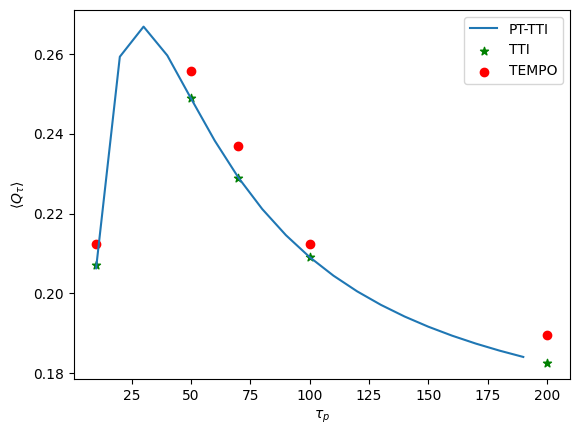

In [140]:
plt.plot(range(10,200,10),tti_pt_heats,label='PT-TTI')
plt.scatter(protocol_times,final_heats,marker='*',c='green',label='TTI')
plt.scatter(protocol_times,final_heats_tempo,marker='o',c='red',label='TEMPO')
plt.xlabel(r'$\tau_p$')
plt.ylabel(r'$\langle Q_\tau \rangle$')
plt.legend()

 36.0%   45 of  125 [##############--------------------------] 16:32:56

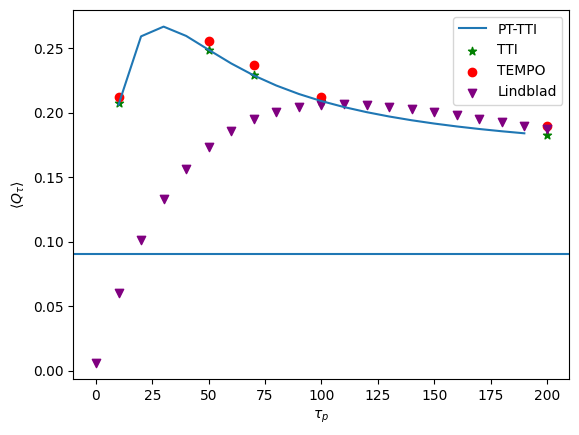

 90.3%  542 of  600 [####################################----] 05:40:10

 90.3%  542 of  600 [####################################----] 05:40:14

In [ ]:
plt.plot(range(10,200,10),tti_pt_heats,label='PT-TTI')
plt.scatter(protocol_times,final_heats,marker='*',c='green',label='TTI')
plt.scatter(protocol_times,final_heats_tempo,marker='o',c='red',label='TEMPO')
plt.scatter(np.linspace(0,200,len(final_heats_lindblad)),final_heats_lindblad,marker='v',c='purple',label='Lindblad')
plt.xlabel(r'$\tau_p$')
plt.axhline(np.log(2)*0.131)
plt.ylabel(r'$\langle Q_\tau \rangle$')
plt.legend()

In [120]:
tempo_heat_dict={10: np.array([0.        , 0.00825542, 0.02646666, 0.04474498, 0.05901149,
       0.06924591, 0.07649249, 0.08172849, 0.08566394, 0.08878648,
       0.09143339, 0.09384002, 0.09618134, 0.09859656, 0.10117832,
       0.10400576, 0.10700944, 0.11025795, 0.11383583, 0.11776616,
       0.12207287, 0.12674835, 0.13176667, 0.13709304, 0.142795  ,
       0.14883902, 0.15519489, 0.16182842, 0.1685834 , 0.17550298,
       0.1825164 , 0.18957219, 0.19707571, 0.20473077, 0.21244801]), 50: np.array([0.        , 0.03288197, 0.06621186, 0.08151873, 0.08872138,
       0.09256116, 0.09488429, 0.09648072, 0.09773156, 0.09884499,
       0.09994655, 0.10112089, 0.10236505, 0.10368152, 0.1051661 ,
       0.10683988, 0.10869053, 0.1107541 , 0.11304201, 0.11553338,
       0.11824787, 0.12119847, 0.12437708, 0.12777642, 0.13138598,
       0.1344206 , 0.13756009, 0.14079236, 0.14409783, 0.14745624,
       0.1508411 , 0.15425979, 0.15773772, 0.16122388, 0.16470668,
       0.16817783, 0.17190556, 0.17545867, 0.17897591, 0.1825523 ,
       0.18607492, 0.18954353, 0.19294649, 0.19627119, 0.1995198 ,
       0.2026733 , 0.20578155, 0.20882018, 0.21173603, 0.21453549,
       0.21723564, 0.2198323 , 0.22224728, 0.22470205, 0.22707215,
       0.22934441, 0.23150833, 0.23357741, 0.23552587, 0.23740218,
       0.23921479, 0.24097903, 0.24272479, 0.2443642 , 0.24601927,
       0.24755416, 0.24891721, 0.25023138, 0.25151885, 0.25271532,
       0.25383242, 0.25485327, 0.25583304]), 70: np.array([0.        , 0.03288197, 0.06621187, 0.08151486, 0.0887015 ,
       0.09250352, 0.09475834, 0.09624186, 0.09732556, 0.09820464,
       0.09899151, 0.09976198, 0.10056218, 0.10142892, 0.10239187,
       0.10339925, 0.10443416, 0.10558448, 0.10683533, 0.10821237,
       0.10971593, 0.11135479, 0.1131375 , 0.11506154, 0.11713382,
       0.11931398, 0.12162221, 0.12404744, 0.12660031, 0.12930613,
       0.13213053, 0.13429985, 0.13651539, 0.13877402, 0.14107094,
       0.14339542, 0.14575087, 0.14811872, 0.15049026, 0.15284039,
       0.15520613, 0.15757031, 0.15995028, 0.16230894, 0.1646364 ,
       0.16693619, 0.16919451, 0.17167606, 0.17397008, 0.17621824,
       0.17842353, 0.18072401, 0.18297739, 0.18518002, 0.18733479,
       0.18943147, 0.19147992, 0.19347841, 0.19540772, 0.19727223,
       0.19907034, 0.20080378, 0.20249962, 0.2041473 , 0.20570675,
       0.20720007, 0.20863583, 0.20999459, 0.2111864 , 0.21230508,
       0.21346969, 0.2146467 , 0.21574656, 0.21689139, 0.21811118,
       0.21928964, 0.22039615, 0.22143231, 0.22246293, 0.2233361 ,
       0.22424494, 0.22519121, 0.22616248, 0.227116  , 0.22805802,
       0.22898943, 0.22985689, 0.23068672, 0.2314211 , 0.23205862,
       0.23289198, 0.23353985, 0.23397776, 0.23439531, 0.23477233,
       0.23512117, 0.23547789, 0.23583113, 0.23624783, 0.23668805,
       0.23700755]), 100: np.array([0.        , 0.03288197, 0.06621188, 0.08151342, 0.08869333,
       0.0924771 , 0.09469467, 0.09611863, 0.09711283, 0.09786567,
       0.0984814 , 0.09901065, 0.09950402, 0.0999892 , 0.10048557,
       0.10100803, 0.10154142, 0.1021065 , 0.10267908, 0.10329328,
       0.10395196, 0.10465655, 0.10540933, 0.10621092, 0.10704722,
       0.10793081, 0.10886449, 0.10984714, 0.11087869, 0.11195711,
       0.11308479, 0.11425681, 0.11547516, 0.11673676, 0.11803956,
       0.11938144, 0.12075948, 0.12217305, 0.12361948, 0.12509571,
       0.12659848, 0.12812528, 0.12967397, 0.13124211, 0.13282982,
       0.13443378, 0.1360438 , 0.13766254, 0.1392865 , 0.1409115 ,
       0.14256754, 0.14422079, 0.14587455, 0.14752776, 0.1491719 ,
       0.15081048, 0.15246626, 0.15411446, 0.15574878, 0.15738874,
       0.15900662, 0.16060891, 0.16219632, 0.16377407, 0.16533814,
       0.16687628, 0.16839271, 0.16989706, 0.17139528, 0.17287661,
       0.17432686, 0.17574221, 0.17713628, 0.17849624, 0.17981653,
       0.18107244, 0.18227537, 0.18341239, 0.18451522, 0.18562418,
       0.1866864 , 0.18772504, 0.18875035, 0.18971414, 0.1906518 ,
       0.19158544, 0.19248354, 0.1933373 , 0.19414107, 0.1949161 ,
       0.19567438, 0.19638175, 0.19707699, 0.19775294, 0.19840619,
       0.19901713, 0.19961221, 0.2001893 , 0.20074239, 0.20131358,
       0.20185126, 0.20236261, 0.20288933, 0.20339795, 0.20390132,
       0.20439816, 0.20489032, 0.20533747, 0.20576111, 0.20616121,
       0.20653423, 0.2069061 , 0.20726158, 0.20760279, 0.207946  ,
       0.20827166, 0.20856963, 0.20884545, 0.2090961 , 0.20933763,
       0.20956139, 0.20976602, 0.20996003, 0.21013646, 0.21030914,
       0.21047784, 0.21062536, 0.21077135, 0.21088479, 0.21100525,
       0.21112222, 0.21123485, 0.21134838, 0.21144337, 0.2115425 ,
       0.21163491, 0.21172799, 0.21182188, 0.21192114, 0.21200695,
       0.21211705, 0.2122281 , 0.21236245, 0.21250073]), 200: np.array([0.        , 0.03288197, 0.06621188, 0.08151205, 0.08868614,
       0.0924559 , 0.09464709, 0.09602785, 0.09695755, 0.09762048,
       0.09811871, 0.09851479, 0.09884435, 0.0991324 , 0.09939616,
       0.09963796, 0.09987462, 0.1000976 , 0.10032358, 0.10055658,
       0.10079958, 0.10105535, 0.10132604, 0.10161355, 0.1019197 ,
       0.10224592, 0.10252604, 0.10283861, 0.10316119, 0.10347572,
       0.10380002, 0.10413699, 0.10448567, 0.10484758, 0.10522206,
       0.10560858, 0.10600865, 0.10642191, 0.10684846, 0.10728818,
       0.10774132, 0.10819358, 0.10865573, 0.10913742, 0.10962954,
       0.11013496, 0.11065724, 0.11118769, 0.11172865, 0.11227885,
       0.11284466, 0.11342106, 0.11400653, 0.11459926, 0.11519973,
       0.11580997, 0.11642718, 0.11705174, 0.11768355, 0.11832146,
       0.11896622, 0.11961642, 0.12027283, 0.12093489, 0.12160338,
       0.12227739, 0.12295579, 0.12363721, 0.12431866, 0.12499943,
       0.12568256, 0.12636684, 0.12704705, 0.12771848, 0.12838882,
       0.12905722, 0.12972437, 0.13038693, 0.13104923, 0.13171009,
       0.1323715 , 0.13302747, 0.13368446, 0.13433756, 0.1349854 ,
       0.13563022, 0.13627275, 0.13691864, 0.13755842, 0.13819918,
       0.13883603, 0.13946712, 0.1401646 , 0.14084905, 0.14152901,
       0.14221121, 0.14288896, 0.14356772, 0.14424662, 0.1449429 ,
       0.14563778, 0.14633261, 0.14704089, 0.14773715, 0.14843225,
       0.14911373, 0.14977977, 0.15044532, 0.15112657, 0.15180537,
       0.15248058, 0.15316366, 0.1538245 , 0.1544817 , 0.15513387,
       0.1557933 , 0.15645124, 0.15710886, 0.15775533, 0.15839425,
       0.15903444, 0.15965933, 0.16027359, 0.16088397, 0.16149121,
       0.16208307, 0.16266487, 0.16323538, 0.16380132, 0.16434372,
       0.16485313, 0.16532053, 0.16576769, 0.16621934, 0.16665586,
       0.16710176, 0.16755238, 0.16797438, 0.16838918, 0.16878369,
       0.16917485, 0.16956078, 0.16994759, 0.17029258, 0.17063237,
       0.17094577, 0.17125788, 0.1715891 , 0.17190033, 0.17217988,
       0.17246301, 0.17272438, 0.17297057, 0.17319373, 0.17342767,
       0.17366237, 0.17388692, 0.1741041 , 0.17431933, 0.17453154,
       0.17471162, 0.17488322, 0.17506031, 0.17523566, 0.17540073,
       0.17558385, 0.1757576 , 0.17591888, 0.17608054, 0.17624032,
       0.17637775, 0.17652231, 0.17667918, 0.17683103, 0.17699264,
       0.17715765, 0.17732831, 0.17747439, 0.17763431, 0.17782903,
       0.17801634, 0.17819883, 0.17841715, 0.17861564, 0.17883185,
       0.17905148, 0.1792599 , 0.17949035, 0.17971038, 0.17993196,
       0.18014371, 0.18037223, 0.18059206, 0.18080078, 0.18102774,
       0.18126174, 0.18149084, 0.18173389, 0.18197823, 0.18220854,
       0.18245483, 0.18267932, 0.18289399, 0.18310888, 0.18332713,
       0.18354161, 0.18375166, 0.18395576, 0.18414443, 0.18432268,
       0.18449386, 0.18466761, 0.18483073, 0.18496936, 0.18510514,
       0.1852331 , 0.18535729, 0.18547815, 0.18558535, 0.18568208,
       0.18575409, 0.18582118, 0.18589281, 0.18595502, 0.18599745,
       0.18603758, 0.18607766, 0.18610324, 0.18611745, 0.18613129,
       0.18613842, 0.1861452 , 0.18614423, 0.186132  , 0.18611151,
       0.1860771 , 0.18603788, 0.18600135, 0.18595445, 0.18591453,
       0.18586035, 0.18581732, 0.18577423, 0.18572348, 0.18567256,
       0.18562056, 0.18557058, 0.18550247, 0.18543888, 0.18537232,
       0.18531267, 0.18525933, 0.1852188 , 0.18517978, 0.18515261,
       0.18513392, 0.18511219, 0.18510241, 0.18510102, 0.18511017,
       0.18513944, 0.18518001, 0.18523854, 0.18530603, 0.18536628,
       0.1854319 , 0.18550889, 0.18560106, 0.18571007, 0.18583701,
       0.1859769 , 0.18613032, 0.18629883, 0.186475  , 0.18666464,
       0.18686523, 0.18707531, 0.18729646, 0.18752087, 0.1877544 ,
       0.18799728, 0.18824738, 0.18850109, 0.18876097, 0.18902409,
       0.18928389, 0.18954784])}

 93.9%  169 of  180 [#####################################---] 04:56:49

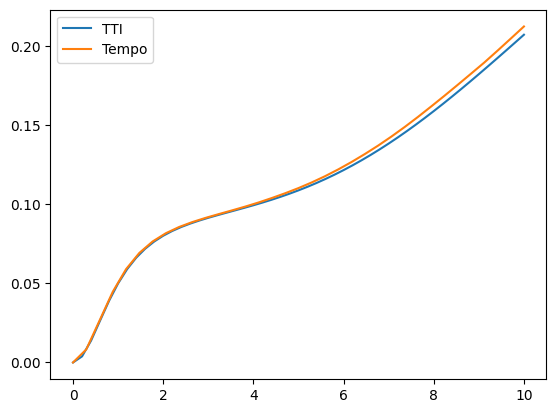

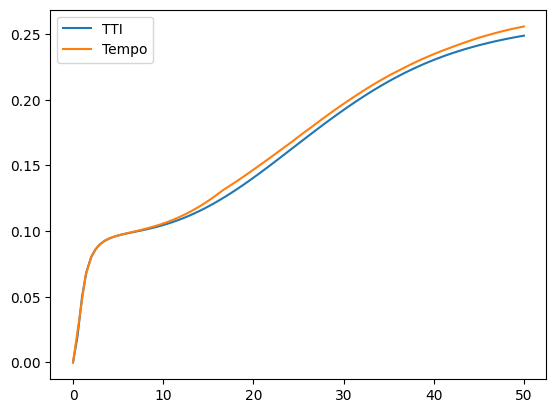

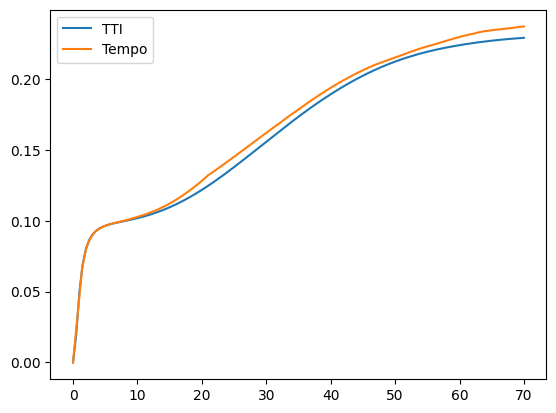

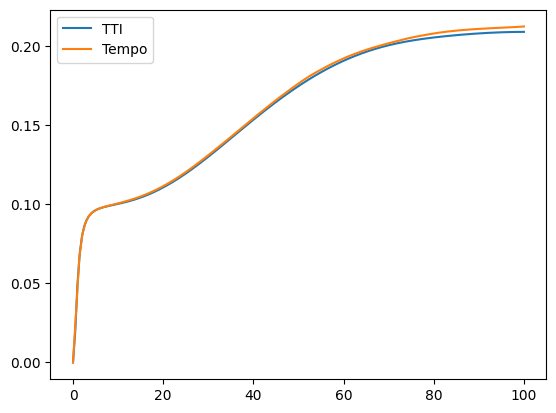

 90.3%  542 of  600 [####################################----] 04:02:23

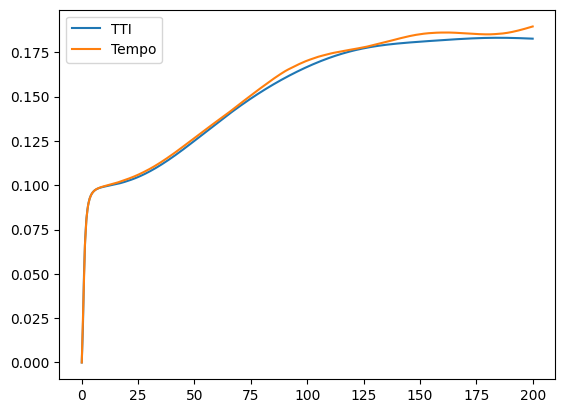

 36.0%   45 of  125 [##############--------------------------] 14:55:23

In [ ]:
for t in protocol_times:
    plt.plot(np.linspace(0,t,len(heats_dict[t])),heats_dict[t],label='TTI')
    plt.plot(np.linspace(0,t,len(tempo_heat_dict[t])),tempo_heat_dict[t],label='Tempo')
    plt.legend()
    plt.show()

 90.3%  542 of  600 [####################################----] 04:33:42

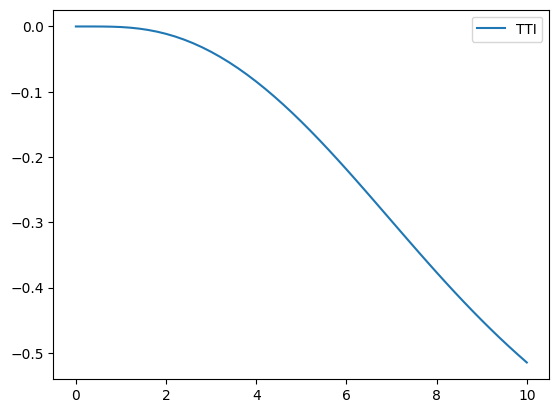

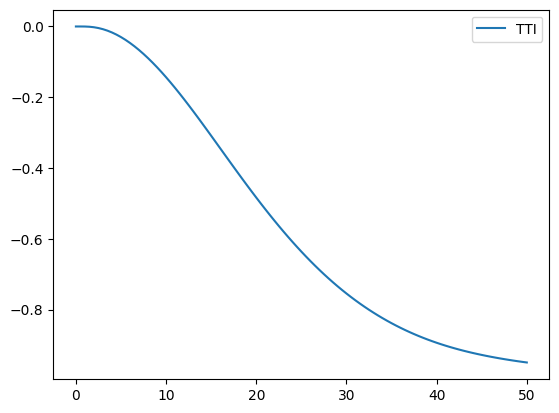

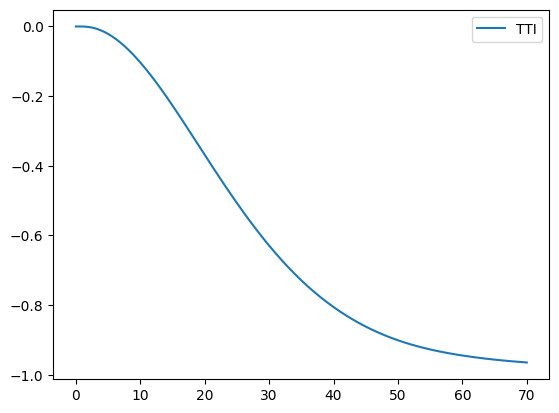

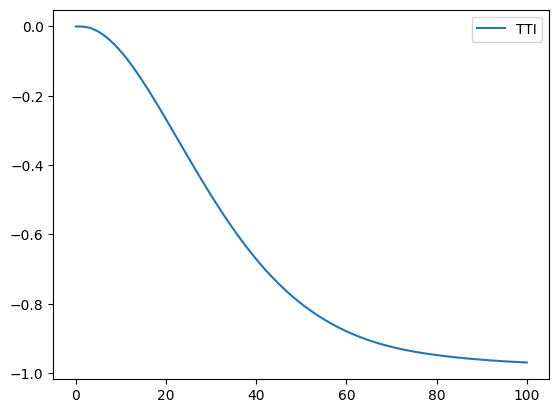

 90.3%  542 of  600 [####################################----] 04:33:43

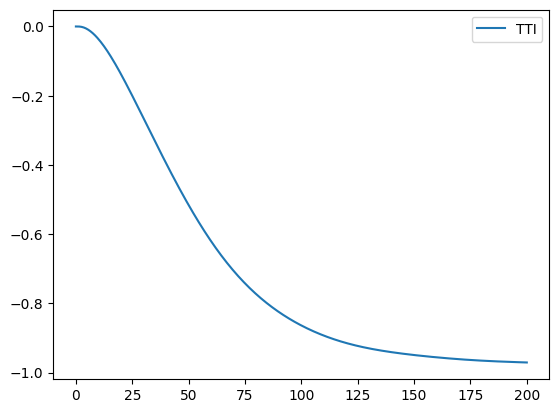

 93.9%  169 of  180 [#####################################---] 06:38:39

In [ ]:
for t in protocol_times:
    plt.plot(np.linspace(0,t,len(dyn_dict[t])),dyn_dict[t],label='TTI')
    plt.legend()
    plt.show()